In [1]:
import numpy as np
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import matplotlib.animation as animation
from matplotlib.patches import ConnectionPatch, Rectangle
from itertools import product

from numpy import datetime64 as dt
from numpy import timedelta64 as td

import cmocean
import xarray as xr
from glob import glob
import cartopy
from cartopy.crs import Geodetic, PlateCarree, Stereographic
import warnings

import pandas as pd
import geopandas as gpd
import seaborn as sns

warnings.simplefilter("ignore")

# Figures to make:
## Main text:

- [x] Figure 1: Connectivity matrix
- [x] Figure 2: Spatial connectivity
- [x] Figure 3: Number of generations it takes to connect all stations

## Supplements:

- Table S1: Station list
- [x] Figure S1: Voronoi areas with stations
- [x] Figure S2: Full connectivity matrix
- [x] Figure S3: Full matrix number of generations it takes to connect all stations

## Meta
as pdf (vector)
include grid
bold textfor real stations

# Set Parameters

In [106]:
# Paths
folder_path = "/gxfs_work/geomar/smomw597/2025_copepods/output/"
# trajectory_path = Path(folder_path, f"Trajectories/{year}/")
sample_Points_path = Path(folder_path, "SamplePoints/SamplePoints.shp")
voronoi_Polygons_path = Path(folder_path, "SamplePoints/VoronoiPolygons.shp")
voronoi_Ocean_path = Path(folder_path, "SamplePoints/VoronoiOceanPolygons.shp")
input_path = Path(folder_path, "VoronoiConnectivity/")

# Load the samplepoints and the voronoi polygons
gdf_sample_points = gpd.read_file(sample_Points_path).to_crs(Geodetic())
gdf_voronoi_polygons = gpd.read_file(voronoi_Polygons_path).to_crs(Geodetic())
gdf_ocean_polygons = gpd.read_file(voronoi_Ocean_path).to_crs(Geodetic())

figure_outpath = Path("/gxfs_work/geomar/smomw597/2025_copepods/Figures/")

In [107]:
gdf_sample_points.to_csv(Path(figure_outpath, "SamplePoints.csv"))

In [3]:
location_names_sorted = gdf_sample_points.sort_values(by="order").SampleID.tolist()
lons = gdf_sample_points.sort_values(by="order").geometry.x.values
lats = gdf_sample_points.sort_values(by="order").geometry.y.values
n_sites = len(gdf_sample_points)
nondigitalSamples = gdf_sample_points.sort_values(by="order").SampleID.where(gdf_sample_points.SampleKind != 'digital').reset_index().drop(columns='index')
digitalSamples = gdf_sample_points.sort_values(by="order").SampleID.where(gdf_sample_points.SampleKind == 'digital').reset_index().drop(columns='index')

years = np.arange(2016,2025)
n_years = len(years)

In [4]:
n_days = (np.datetime64("2016-11-01", "D") - np.datetime64("2016-06-01", "D")).astype("int")
n_timesteps_day = 24*4
n_days_life = 28
n_days_adult = 18
n_particles = 1000
# Check wether n_timesteps_day is needed oreven wrong here
n_total = n_days * n_years * n_timesteps_day * n_days_life * n_sites * n_particles
n30d = 30 * n_years * n_timesteps_day * n_days_life * n_sites * n_particles
n31d = 31 * n_years * n_timesteps_day * n_days_life * n_sites * n_particles

total_particle_count_per_site = n_days * n_years * n_particles
max_observation_single_particle = n_days_adult * n_timesteps_day

In [5]:
# Set the basic mapping parameters
suptitle_size = 20
title_size = 16
mapsize = (16, 8)
extent = (2.5, 27.5, 52, 62)
lonmid = np.mean(extent[:2])
latmid = np.mean(extent[2:])
map_projection = Stereographic(
    central_longitude=lonmid, central_latitude=latmid,
    )
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(LAND)
    ax.add_feature(COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [ ]:
# input_path = Path("/gxfs_work/geomar/smomw597/2025_copepods/output/")

# Functions

In [7]:
def sort_cmatrix(matrix_in):
    matrix = matrix_in[location_names_sorted + [c for c in matrix_in.columns if c not in location_names_sorted]]
    return matrix.reindex(location_names_sorted)

In [8]:
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [9]:
def highlight_single_cell(ax, idx):
        return ax.add_patch(Rectangle((idx, idx),1,1, fill=False, edgecolor='k', lw=1, zorder=3))

def highlight_col(ax, idx, length):
        # ax.add_patch(Rectangle((idx, 0),1,length, fill=False, edgecolor='red', lw=1, zorder=1))
        return ax.add_patch(Rectangle((idx, 0),1,length, fill=True, color='lightgray', edgecolor='red', lw=1, alpha=0.3, zorder=0))
def highlight_row(ax, idx, length):
        return ax.add_patch(Rectangle((0, idx),length,1, fill=True, color='lightgray', lw=0.5, alpha=0.3, zorder=0))
        # return ax.add_patch(Rectangle((0, idx),length,1, fill=False, edgecolor='lightgray', lw=1, zorder=1))

def draw_guides(ax):
        length = len(df_cmatrix_total.index)
        digitalSamples_list = digitalSamples.dropna().values.T[0]
        for idx, site_name in enumerate(df_cmatrix_total.index):
                if site_name not in digitalSamples_list:
                        highlight_col(ax, idx, length)
                        highlight_row(ax, idx, length)
        return ax

In [10]:
def build_ax(ax, fontsize=10, labelpad=15, xlabelposition="top", no_digital=False,):
        ax.xaxis.set_label_position(xlabelposition)  
        # ax.set_yticklabels(ax.get_yticklabels(), rotation=90)
        pad = 5
        if xlabelposition == "top":
                ax.tick_params(
                        grid_linewidth=0, labelsize=fontsize, 
                        labelbottom=False, labeltop=True, 
                        size=0, pad=pad,
                        )
        if not no_digital:
                pad = 2
                for x_tick, y_tick in zip(ax.get_xticklabels(), ax.get_yticklabels()):
                        if x_tick.get_text() not in digitalSamples.dropna().values.T[0]:
                                x_tick.set_fontweight("bold")
                                y_tick.set_fontweight("bold")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0,)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90,)
        ax.set_ylabel("Source Stations", size=fontsize, labelpad=labelpad)
        ax.set_xlabel("Target Stations", size=fontsize, labelpad=labelpad)
        return ax

def define_cmap(cmap_name='coolwarm', cmdiscrete=False,value_min=None, value_max=None):
        cmap = plt.get_cmap(cmap_name)
        vmax = 10**np.ceil(np.log10(value_max))
        vmin = 10**np.floor(np.log10(value_min))
        sample_steps = vmax-vmin
        bounds = np.arange(vmin, vmax+1)
        fmt = ".0f"
        norm = mpl.colors.Normalize(vmin=value_min, vmax=value_max)
        # resample the colormap into the amount of discrete steps of difference between the vmin and vmax in power of 10
        steps = (np.log10(vmax) - np.log10(vmin)).astype(int) 
        if steps >2:
                sample_steps = steps
                bounds = np.logspace(np.log10(vmin), np.log10(vmax), steps+1)
                fmt = ".0e"
                norm = LogNorm(vmin=vmin, vmax=vmax,)
        if cmdiscrete == True:
                cmap = cmap.resampled(sample_steps)
                cmap.set_under(color="#00000000") # force the first color entry to be invisible
        return cmap, bounds, fmt, norm

def drop_digital(matrix, no_digital):
        if no_digital == True:
                digitalSamples_list = digitalSamples.dropna().values.T[0]
                return matrix.drop(columns=digitalSamples_list, index=digitalSamples_list)
        return matrix

def showConnectivityMatrix(matrix, fn = None, vmin = None, vmax = None, no_digital=True, cmap="coolwarm",
        cbtitle=None, cmdiscrete=False, fontsize=10, titlesize=12, annot=True, fmt = ".0e",
        draw_cbar=True, figsize=(7, 7), filename=None):

        matrix = drop_digital(matrix, no_digital)
        value_max = matrix.max(axis=None)
        value_min = matrix.where(matrix != 0).min(axis=None)
        
        cmap, bounds, fmt, norm = define_cmap(cmdiscrete=cmdiscrete, value_max=value_max, value_min=value_min, cmap_name=cmap)
        cbar_format = "%"+fmt
        mask = matrix == 0
        cbar_kws = dict(label=cbtitle, norm=norm, format=cbar_format, ticks=bounds,)
        if draw_cbar:
                fig, (ax, cbar_ax) = plt.subplots(nrows=1, ncols=2, figsize=(8, 7), gridspec_kw={"width_ratios":(0.9, 0.05),},)
        else:
                fig, ax = plt.subplots(nrows=1, ncols=1, figsize=figsize)
                cbar_ax = ax
        fig.suptitle(f"Connectivity Matrix - Voronoi (All Years)", size=titlesize)
        sns.heatmap(
                matrix, mask=mask, cmap=cmap, ax=ax, 
                linewidths=0.5, linecolor="lightgrey",
                norm=norm, square=True,
                annot=annot, fmt=fmt, annot_kws={"size": fontsize},
                cbar=draw_cbar, cbar_kws=cbar_kws, cbar_ax=cbar_ax,
        )
        if draw_cbar:
                cbar_ax.minorticks_off()
        if not no_digital:
                ax = draw_guides(ax)
        ax = build_ax(ax, fontsize=fontsize, no_digital=no_digital)
        plt.tight_layout()
        if filename != None:
                plt.savefig(Path(figure_outpath, filename), format="pdf")
        return plt.show()

# Connectivity Matrices

In [11]:
connectivity_matrix_voronoi_list = sorted(input_path.glob(f'*'))
print(len(connectivity_matrix_voronoi_list))

for i, matrix_link in enumerate(connectivity_matrix_voronoi_list): 
    if i == 0:
        connectivity_matrix = pd.read_csv(connectivity_matrix_voronoi_list[0], index_col=0)
    else:
        connectivity_matrix = connectivity_matrix + pd.read_csv(connectivity_matrix_voronoi_list[0], index_col=0)

9


In [12]:
df_cmatrix_total = sort_cmatrix(connectivity_matrix)
df_cmatrix_normalized = df_cmatrix_total.copy()

df_cmatrix_relative = df_cmatrix_total.copy()/(max_observation_single_particle * total_particle_count_per_site)

for i, column in enumerate(df_cmatrix_total.columns):
        area = gdf_ocean_polygons.loc[i,'area']
        count = df_cmatrix_total.loc[:,column]
        normalized_count = (count/area)*25
        df_cmatrix_normalized.loc[:,column] = normalized_count
df_cmatrix_normalized_relative = df_cmatrix_normalized.copy()/(max_observation_single_particle * total_particle_count_per_site)

In [13]:
df = df_cmatrix_normalized_relative.copy()
value_max = df_cmatrix_normalized_relative.max(axis=None)
value_min = df_cmatrix_normalized_relative.where(df_cmatrix_normalized_relative != 0).min(axis=None)

labels = np.arange(np.floor(np.log10(value_min)),np.ceil(np.log10(value_max)))
for col in df_cmatrix_normalized_relative.columns:
        df[col] = pd.cut(
                df_cmatrix_normalized_relative[col], np.logspace(np.floor(np.log10(value_min)),
                np.ceil(np.log10(value_max)), len(labels)+1), right=False, labels=labels).astype("category")
cmatrix = df_cmatrix_normalized_relative.copy()
generations_matrix = df_cmatrix_normalized_relative.where(cmatrix==0, 1)
for i in np.arange(2,25):
        cmatrix = df_cmatrix_normalized_relative.dot(cmatrix)
        generations_matrix = generations_matrix.where((generations_matrix[generations_matrix == 0].isnull()) | (cmatrix==0), i)
        if generations_matrix.min(axis=None) != 0:
                break

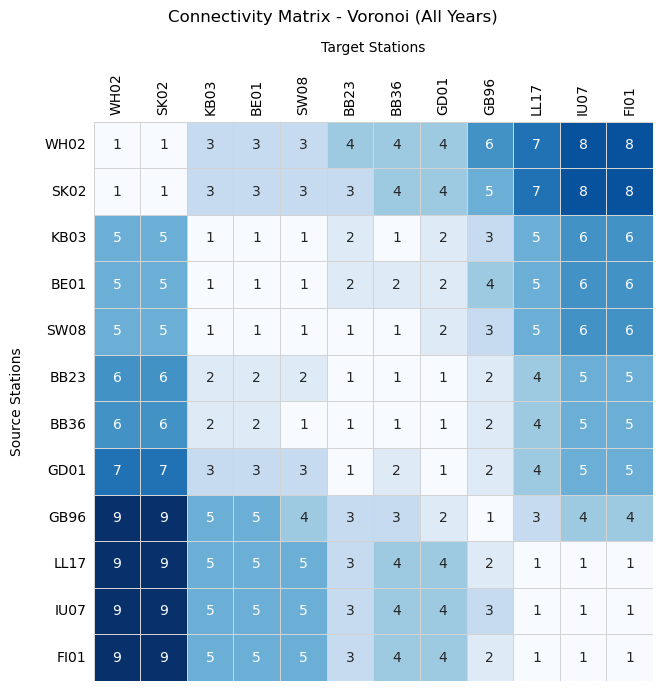

In [14]:
showConnectivityMatrix(generations_matrix, no_digital=True, cbtitle="", cmdiscrete=True, 
    cmap="Blues", draw_cbar=False, filename="Generation_matrix.pdf")

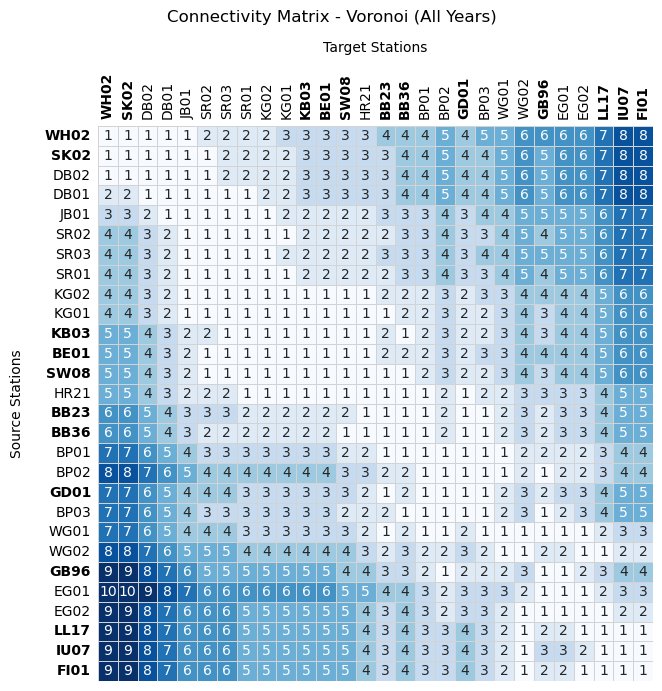

In [28]:
showConnectivityMatrix(generations_matrix, no_digital=False, cbtitle="", cmdiscrete=True, 
    cmap="Blues", draw_cbar=False, filename="Generation_matrix_all.pdf")

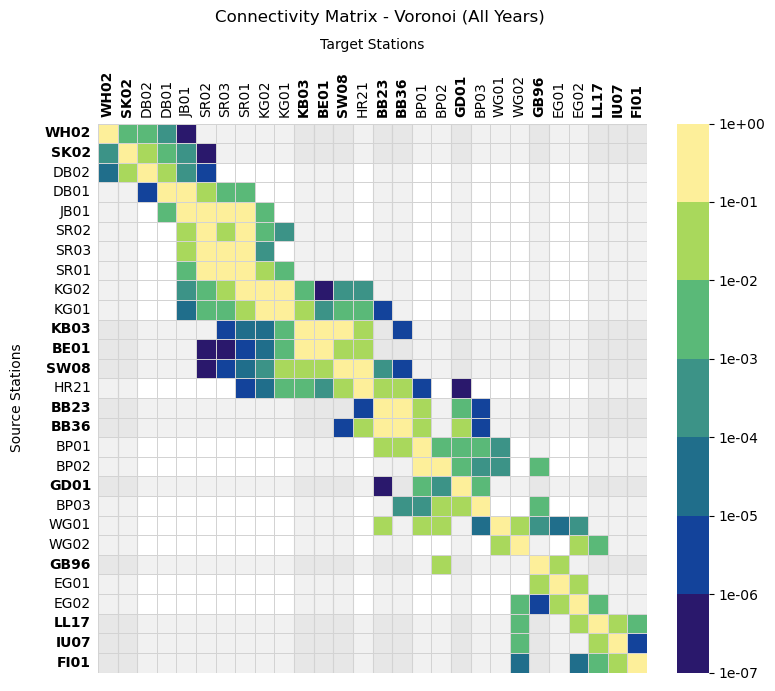

In [15]:
showConnectivityMatrix(df_cmatrix_relative, annot=False ,no_digital=False, cbtitle="", cmdiscrete=True, cmap=cmocean.cm.haline,
    filename="Connectivity_matrix_all.pdf")

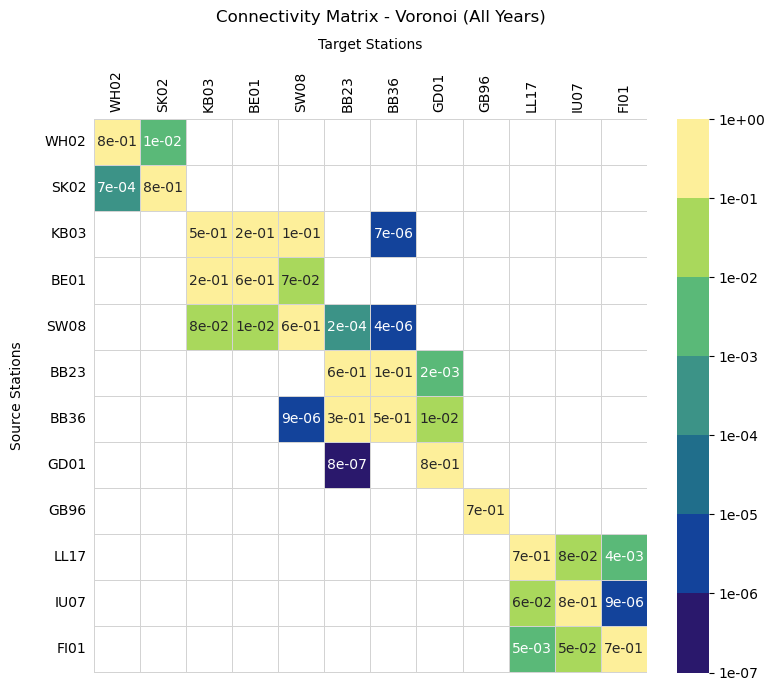

In [31]:
showConnectivityMatrix(df_cmatrix_relative, annot=True ,no_digital=True, cbtitle="", cmdiscrete=True, cmap=cmocean.cm.haline,
    filename="Connectivity_matrix.pdf")

# Maps

In [15]:
gdf_sample_points = gdf_sample_points.to_crs(map_projection)

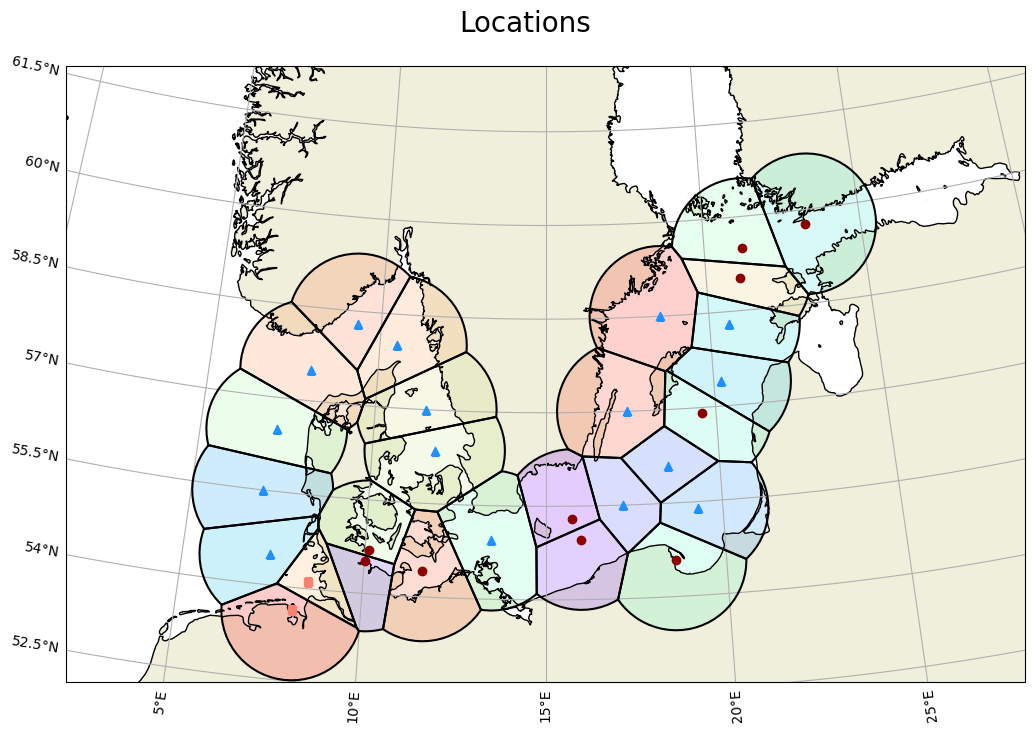

In [16]:
# Fix positions
voronoi_polys = gdf_voronoi_polygons.copy().to_crs(map_projection)
show_polygons = True
fig = plt.figure(figsize=mapsize)
fig.suptitle("Locations", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
if show_polygons:
        voronoi_polys.plot(ax=ax_map, alpha=0.2, column="PolygonID", cmap="rainbow")
        voronoi_polys.boundary.plot(ax=ax_map, color="k", )
# Add the red dots for the non sampled points
marker_style = dict()
# gdf_sample_points.to_crs(map_projection).plot(ax=ax_map, column="SampleKind", legend=True,)
lat = gdf_sample_points.to_crs(map_projection).geometry.y
lon = gdf_sample_points.to_crs(map_projection).geometry.x
# ax_map.scatter(lon, lat, marker=)
for i in gdf_sample_points.index:
        lon = gdf_sample_points.geometry.x[i]
        lat = gdf_sample_points.geometry.y[i]
        kind = gdf_sample_points.SampleKind[i]
        marker = dict(real="o", digital="^", moved="s")[kind]
        color = dict(real="darkred", digital="dodgerblue", moved="salmon")[kind]
        ax_map.scatter(lon, lat, marker=marker, color=color, zorder=5,)
# gdf_sample_points.to_crs(map_projection).plot(ax=ax_map, column="SampleKind", legend=True,)

plt.savefig(Path(figure_outpath, "EmptyMap.pdf"), format="pdf")
plt.show()

## Connectivity Map

In [17]:
def define_cmap(cmap_input):
        if type(cmap_input) == str:
                return mpl.colormaps.get_cmap(cmap_input)
        elif type(cmap_input) == type(cmocean.cm.haline):
                return cmap_input
        elif type(cmap_input) != type(cmocean.cm.haline):
                return print("Please input colormap or colormap name (str).")

In [97]:
def draw_connections(fig, ax, matrix, 
        cmap_scatter=cmocean.cm.matter, cmap_arrows = cmocean.cm.haline,
        norm=None):
        sample_points = gdf_sample_points.copy().sort_values(by="order").to_crs(map_projection)
        min_connection, max_connection = matrix.min(axis=None), matrix.max(axis=None)
        for (incomming, outgoing) in product(matrix, repeat=2):
                n_connections = matrix[outgoing][incomming]
                if np.isnan(n_connections):
                        continue # don't draw if there are noe connections
                
                geom_outgoing = sample_points[sample_points.SampleID == outgoing].geometry
                xy_outgoing = getXY(geom_outgoing)
                con_size = (n_connections/max_connection)
                if outgoing == incomming:
                        color_scatter = cmap_scatter(norm(n_connections),)
                        geom_outgoing.plot(ax=ax, color=color_scatter, markersize=con_size*500, zorder=2,)
                        continue
                
                geom_incomming = sample_points[sample_points.SampleID == incomming].geometry
                xy_incomming = getXY(geom_incomming)

                incomming_in_extent = ax.get_extent()[0] < xy_incomming[0] < ax.get_extent()[1]
                outgoing_in_extent = ax.get_extent()[0] < xy_outgoing[0] < ax.get_extent()[1]
                if incomming_in_extent and outgoing_in_extent:
                        con_alpha = (n_connections/max_connection)**(1/60)
                        con_lw = (n_connections/max_connection)**(1/15)
                        color_arrow = cmap_arrows(norm(n_connections))

                        con = ConnectionPatch(
                                xyA=xy_outgoing, xyB=xy_incomming, coordsA=ax.transData,
                                color=color_arrow, lw=con_lw*4, alpha=con_alpha, zorder=5
                        )
                        con.set_arrowstyle("-|>,head_length=0.4,widthB=1")
                        con.set_connectionstyle("Arc3,rad=0.2")
                        ax.add_artist(con)

In [19]:
def plot_voronoi_polygons(ax, cmap="rainbow", edgecolor="black", facealpha=0.2):
        voronoi_polys.plot(ax=ax, alpha=facealpha, column="PolygonID", cmap=cmap)
        voronoi_polys.boundary.plot(ax=ax, color=edgecolor,)

In [24]:
def getXY(pt):
    return (pt.x.values[0], pt.y.values[0])

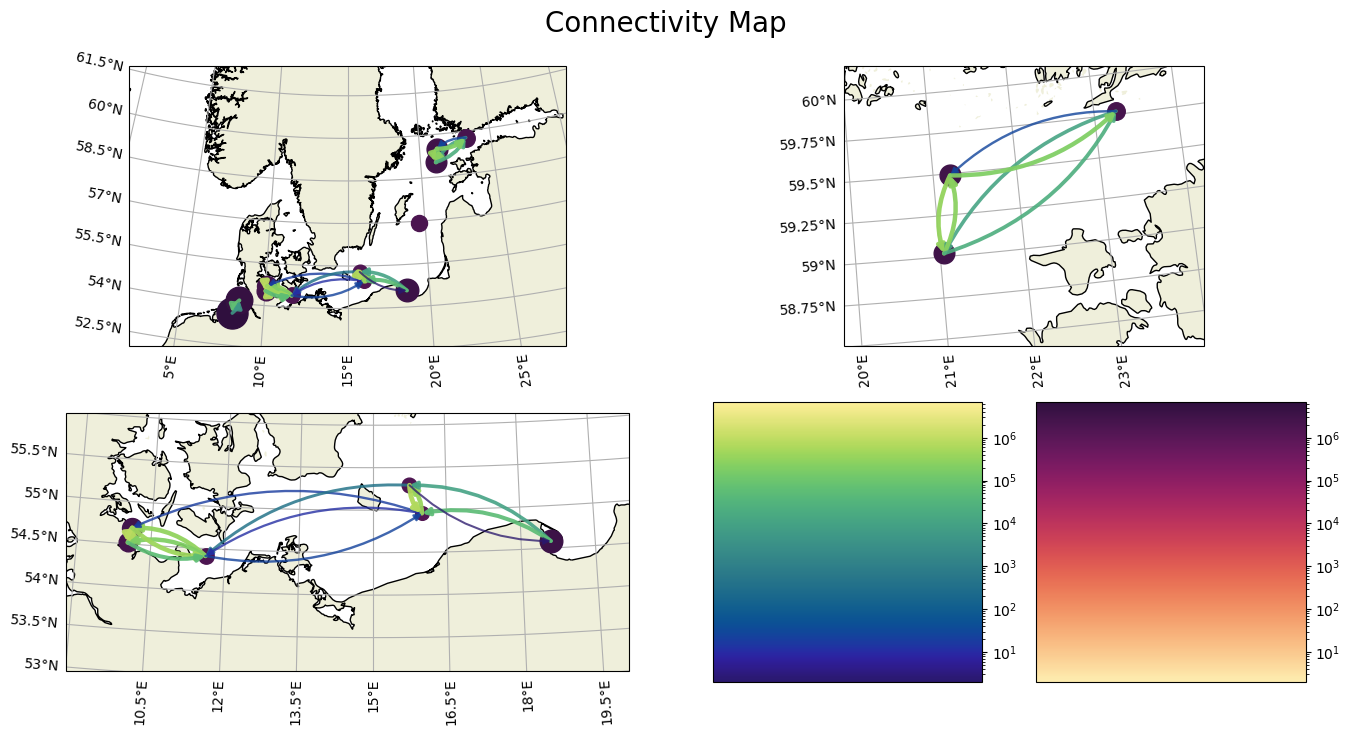

In [99]:
def make_connectivitymap(
        matrix, 
        map_projection=map_projection, mapsize=mapsize, suptitle="Connectivity Map",
        no_digital=True, show_polygons=False, 
        cmap_scatter=cmocean.cm.matter, cmap_arrows = cmocean.cm.haline,
        filename=None,
        ):
        matrix = matrix.mask(matrix == 0)
        sample_points = gdf_sample_points.copy().sort_values(by="order").to_crs(map_projection)
        voronoi_polys = gdf_voronoi_polygons.copy().to_crs(map_projection)

        matrix = drop_digital(matrix, no_digital)
        if no_digital:
                voronoi_polys = voronoi_polys[voronoi_polys['SampleKind'] != 'digital']
                sample_points = sample_points[sample_points["SampleKind"] != "digital"]
        if show_polygons:
                plot_voronoi_polygons(ax=ax_main)
        
        min_connection, max_connection = matrix.min(axis=None), matrix.max(axis=None)
        norm = LogNorm(vmin=min_connection, vmax=max_connection)
        cmap_arrows = define_cmap(cmap_arrows)
        cmap_scatter = define_cmap(cmap_scatter)
        
        fig = plt.figure(figsize=mapsize)
        fig.suptitle(suptitle, size=suptitle_size, y=0.95)

        ax_main = fig.add_subplot(221, projection=map_projection)
        basemap(ax_main)
        draw_connections(fig, ax_main, matrix, cmap_arrows=cmap_arrows, cmap_scatter=cmap_scatter, norm=norm)
        ax_northbaltic = fig.add_subplot(222, projection=map_projection)
        basemap(ax_northbaltic)
        ax_northbaltic.set_extent([20, 24, 58.5, 60,], PlateCarree())
        draw_connections(fig, ax_northbaltic, matrix, cmap_arrows=cmap_arrows, cmap_scatter=cmap_scatter, norm=norm)
        northbaltic_extent = ax_northbaltic.get_extent()

        ax_westbaltic = fig.add_subplot(223, projection=map_projection)
        basemap(ax_westbaltic)
        ax_westbaltic.set_extent([9,20,53,56,], PlateCarree())
        draw_connections(fig, ax_westbaltic, matrix, cmap_arrows=cmap_arrows, cmap_scatter=cmap_scatter, norm=norm)
        westbaltic_extent = ax_westbaltic.get_extent()

        cax_arrows = fig.add_subplot(247,)
        fig.colorbar(mpl.cm.ScalarMappable(norm, cmap_arrows), cax=cax_arrows, aspect=10, shrink=0.1)
        cax_scatter = fig.add_subplot(248,)
        fig.colorbar(mpl.cm.ScalarMappable(norm, cmap_scatter), cax=cax_scatter, aspect=0.1)
        if filename != None:
                plt.savefig(Path(figure_outpath, filename), format="pdf")

        plt.show()

matrix=df_cmatrix_normalized.copy()
make_connectivitymap(matrix=matrix, filename="ConnectivityMap.pdf")

8    POINT (-452849.288 -352225.841)
Name: geometry, dtype: geometry
7    POINT (-424851.122 -301938.975)
Name: geometry, dtype: geometry
8    POINT (-452849.288 -352225.841)
Name: geometry, dtype: geometry
7    POINT (-424851.122 -301938.975)
Name: geometry, dtype: geometry
0    POINT (-315630.74 -245842.975)
Name: geometry, dtype: geometry
2    POINT (-321499.888 -264983.54)
Name: geometry, dtype: geometry
1    POINT (-219656.292 -282707.334)
Name: geometry, dtype: geometry
25    POINT (63949.402 -226809.779)
Name: geometry, dtype: geometry
0    POINT (-315630.74 -245842.975)
Name: geometry, dtype: geometry
2    POINT (-321499.888 -264983.54)
Name: geometry, dtype: geometry
1    POINT (-219656.292 -282707.334)
Name: geometry, dtype: geometry
0    POINT (-315630.74 -245842.975)
Name: geometry, dtype: geometry
2    POINT (-321499.888 -264983.54)
Name: geometry, dtype: geometry
1    POINT (-219656.292 -282707.334)
Name: geometry, dtype: geometry
24    POINT (47671.941 -190012.064)
Name:

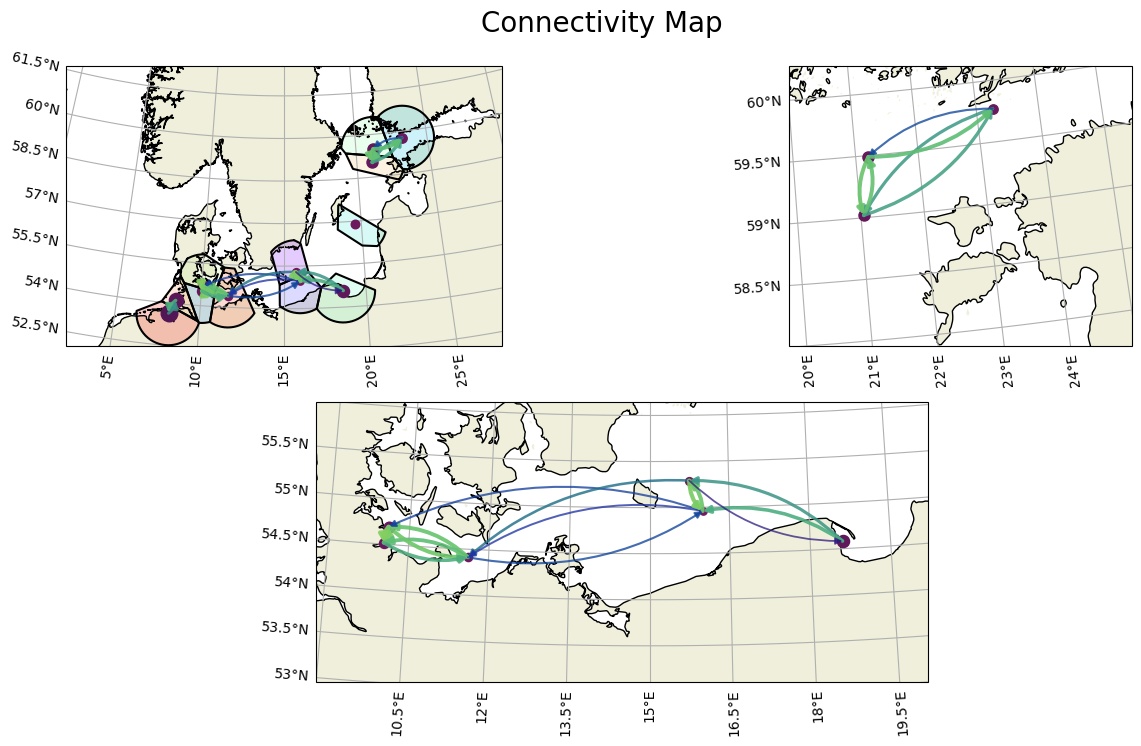

In [ ]:
# Colorbar hinzufuegen
no_digital = True
show_polygons = True
cmap_scatter = cmocean.cm.matter
cmap_arrows = cmocean.cm.haline

voronoi_polys = gdf_voronoi_polygons.copy().to_crs(map_projection)
matrix = df_cmatrix_normalized.copy()
matrix = matrix.mask(matrix == 0)

sample_points = gdf_sample_points.copy().sort_values(by="order").to_crs(map_projection)

min_connection, max_connection = matrix.min(axis=None), matrix.max(axis=None)
lognorm = LogNorm(vmin=min_connection, vmax=max_connection)

matrix = drop_digital(matrix, no_digital)
if no_digital:
        voronoi_polys = voronoi_polys[voronoi_polys['SampleKind'] != 'digital']
        sample_points = sample_points[sample_points["SampleKind"] != "digital"]

fig = plt.figure(figsize=mapsize)
fig.suptitle("Connectivity Map", size=suptitle_size, y=0.95)

ax_main = fig.add_subplot(221, projection=map_projection)
basemap(ax_main)
draw_connections(fig, ax_main, matrix, cmap_arrows=cmap_arrows, cmap_scatter=cmap_scatter)

ax_northbaltic = fig.add_subplot(222, projection=map_projection)
basemap(ax_northbaltic)
ax_northbaltic.set_extent([20, 25,58,60,], PlateCarree())
draw_connections(fig, ax_northbaltic, matrix, cmap_arrows=cmap_arrows, cmap_scatter=cmap_scatter)
northbaltic_extent = ax_northbaltic.get_extent()

ax_westbaltic = fig.add_subplot(212, projection=map_projection)
basemap(ax_westbaltic)
ax_westbaltic.set_extent([9,20,53,56,], PlateCarree())
draw_connections(fig, ax_westbaltic, matrix, cmap_arrows=cmap_arrows, cmap_scatter=cmap_scatter)
westbaltic_extent = ax_westbaltic.get_extent()

if show_polygons:
        # voronoi_polys.plot(ax=ax_main, alpha=0.2, column="PolygonID", cmap="rainbow")
        # voronoi_polys.boundary.plot(ax=ax_main, color="k", )
        plot_voronoi_polygons(ax=ax_main)


plt.savefig(Path(figure_outpath, "ConnectivityMap.pdf"), format="pdf")
plt.show()